# CRM Report

The following report is an exploratory data analysis of two tables from
the customer relationship management (CRM) database.

We’ll first load the CRM data tables.

In [8]:
import polars as pl
from plotnine import *
from pyhere import here

# Load data.
customer_data = pl.read_csv(here('data', 'customer_data.csv'))
store_transactions = pl.read_csv(here('data', 'store_transactions.csv'))

Now we can start summarizing the data.

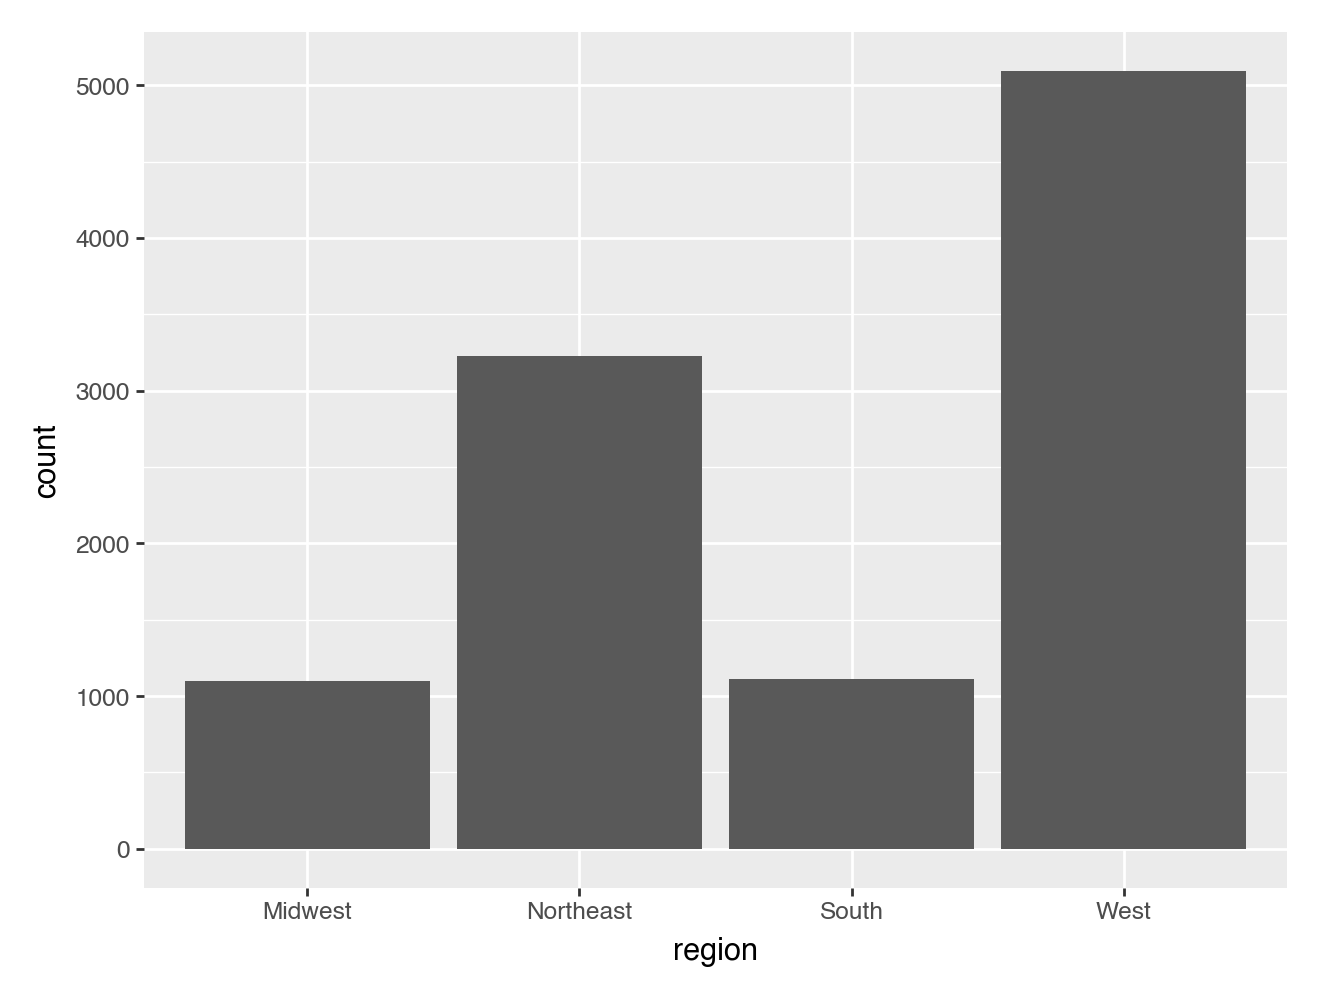

In [9]:
# Visualize customers by region.
(ggplot(customer_data, aes(x = 'region'))
  + geom_bar()
)

Clearly most customers are in the West region.

In [10]:
# Number of customers by region.
(customer_data
  .group_by(pl.col('region'))
  .agg(n = pl.len())
)

region,n
str,u32
"""West""",5095
"""Northeast""",3224
"""South""",1111
"""Midwest""",1101


There are a total of 5,095 customers in the West region.

/Users/a00714634/Documents/pydata/.venv/lib/python3.13/site-packages/plotnine/stats/stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 48'. Pick better value with 'binwidth'.


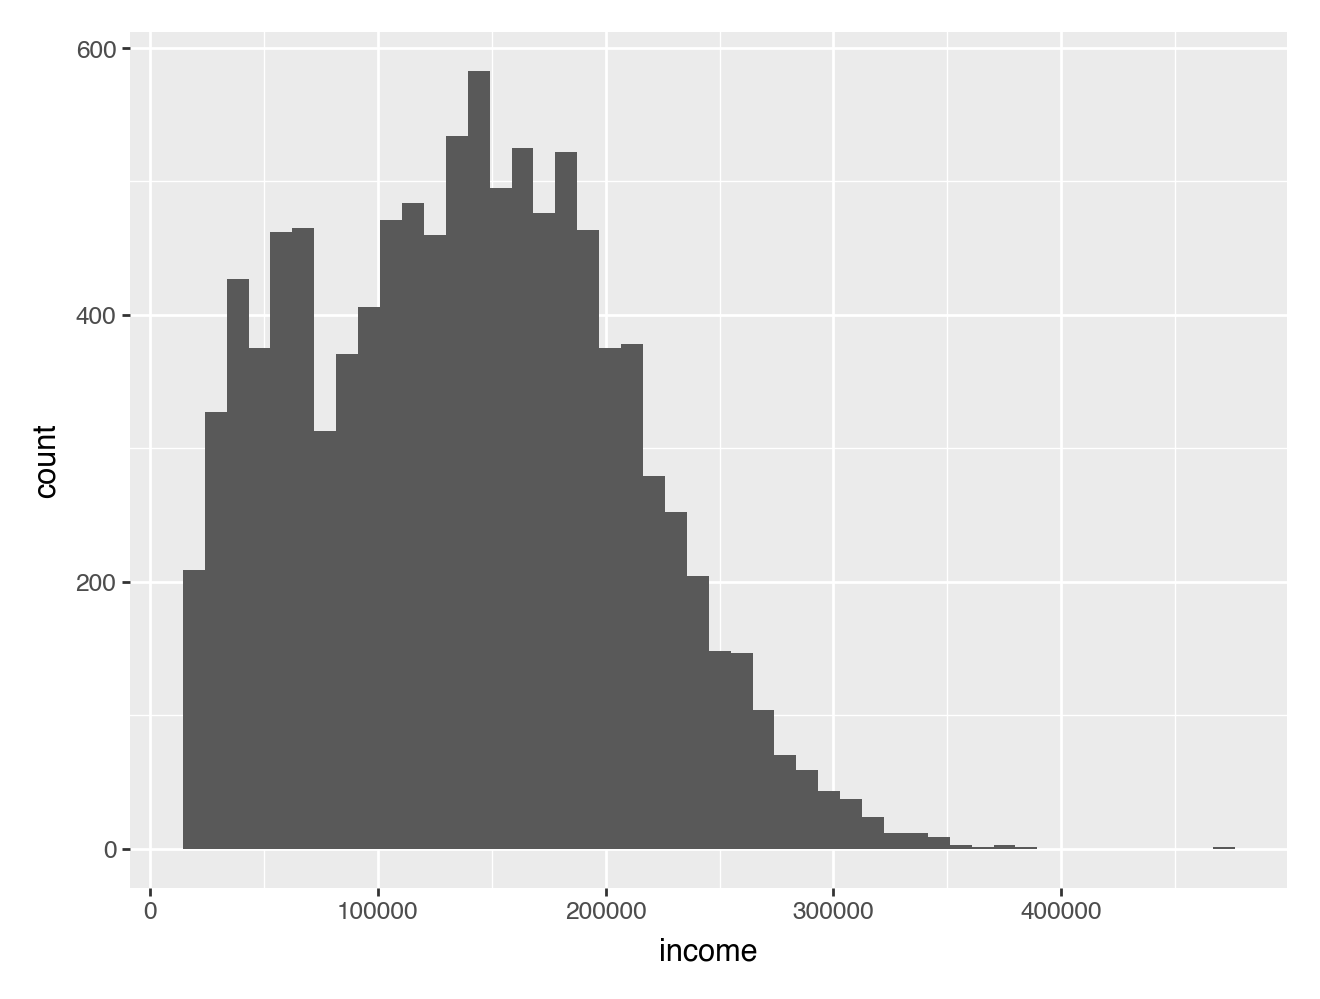

In [11]:
# Visualize income distribution.
(ggplot(customer_data, aes(x="income"))
  + geom_histogram()
)

It looks like the average income across customers is around \$150,000
with a trailing right tail.

In [12]:
# Average customer income.
(customer_data
  .select(pl.col('income'))
  .mean()
)

income
f64
138622.637926


The average income is exactly \$138,622.64.

/Users/a00714634/Documents/pydata/.venv/lib/python3.13/site-packages/plotnine/stats/stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 48'. Pick better value with 'binwidth'.


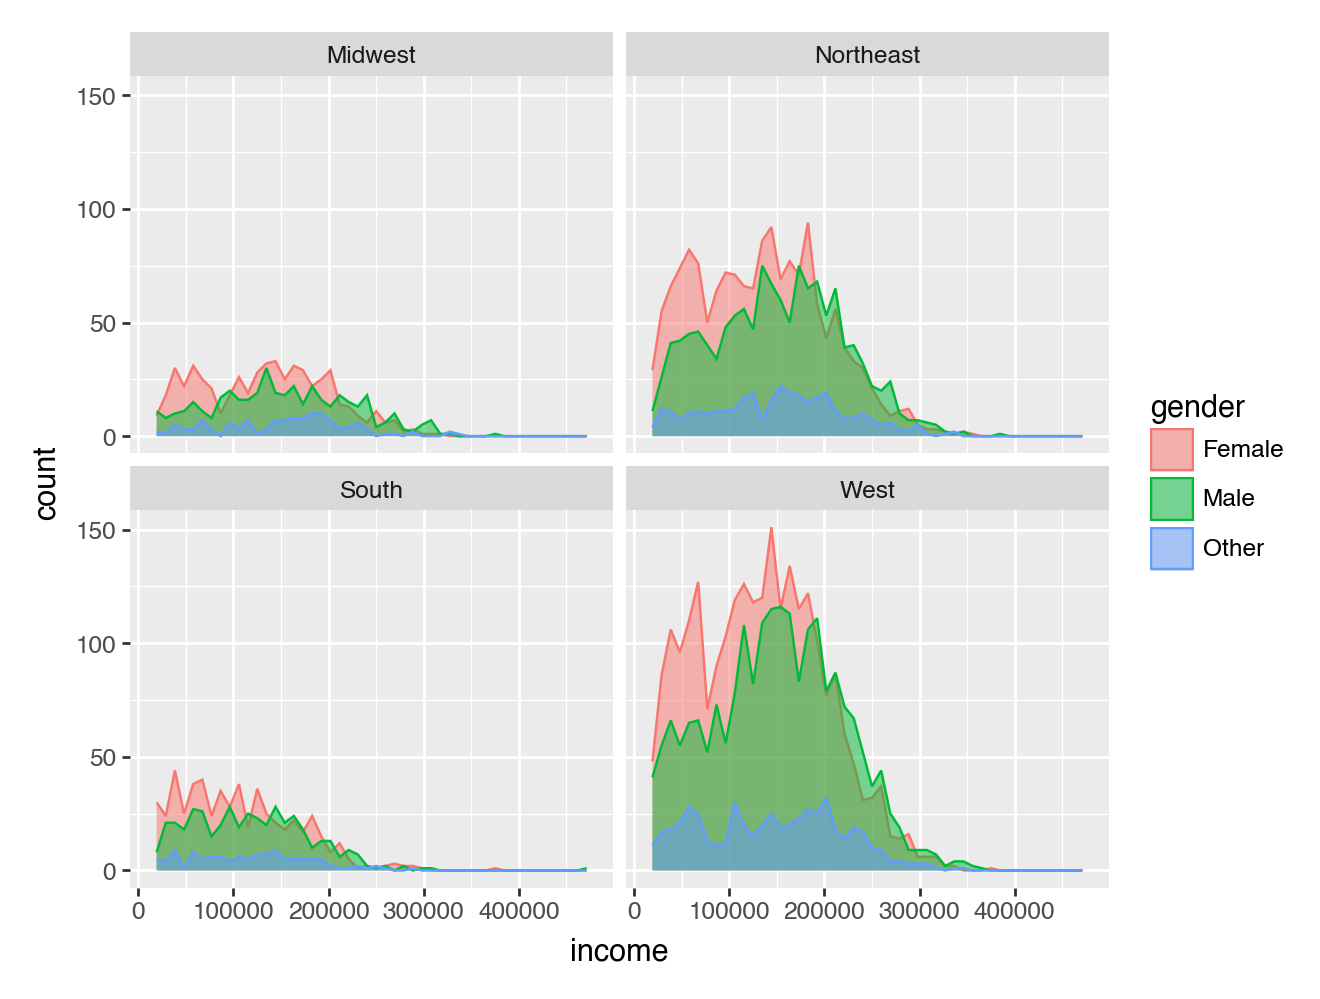

In [13]:
# Visualize relationship between income and gender by region.
(ggplot(customer_data, aes(x="income", fill="gender", color="gender"))
  + stat_bin(geom="area", alpha=0.5, position="identity")
  + facet_wrap("~region")
)

We can look at far more sophisticated visualizations. Here we can see
that the relationship between income and gender doesn’t vary by region.

In [14]:
# Summary of average income and credit by gender and region.
(customer_data
  .group_by(pl.col(['gender', 'region']))
  .agg(
    n = pl.len(), 
    avg_income = pl.col('income').mean()
  )
  .sort(pl.col('avg_income'), descending=True)
)

gender,region,n,avg_income
str,str,u32,f64
"""Other""","""Midwest""",124,154637.096774
"""Male""","""Midwest""",420,152466.666667
"""Other""","""Northeast""",337,150563.79822
"""Male""","""Northeast""",1285,150498.054475
"""Male""","""West""",2079,149452.621453
…,…,…,…
"""Female""","""West""",2497,133818.582299
"""Female""","""Northeast""",1602,133332.709114
"""Other""","""South""",118,119067.79661


And here are the associated numeric summaries of those same variables.

In [ ]:
# How old is the customer in the West who purchased the most in Feb 2005?
(customer_data
  .join(store_transactions, on='customer_id', how='left')
  .filter(pl.col('region') == 'West', pl.col('feb_2005') == pl.col('feb_2005').max())
  .with_columns(age = 2024 - pl.col('birth_year'))
  .select(pl.col(['age', 'feb_2005']))
  .sort(pl.col('age'), descending = True)
  .slice(0, 1)
)

age,feb_2005
i64,i64
67,5
